<a href="https://colab.research.google.com/github/syhaoo/DIP/blob/main/plots/foms_plot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ADC Survey: FOM<sub>S</sub> Plot

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
try:
    from google.colab import files
    IN_COLAB = True
except:
    IN_COLAB = False

In [8]:
# Read latest survey data and concatenate ISSCC and VLSI data
# if IN_COLAB:
#     data = "https://github.com/bmurmann/ADC-survey/blob/main/xls/ADCsurvey_latest.xlsx?raw=true"
# else:
#     data = "../xls/ADCsurvey_latest.xlsx"

data = "ADCsurvey_latest.xlsx"
df1 = pd.read_excel(data, sheet_name='ISSCC')
df2 = pd.read_excel(data, sheet_name='VLSI')
df = pd.concat([df1, df2])

In [3]:
# Show headers of data table
print(df.keys())

Index(['YEAR', 'ID', 'TYPE', 'ARCHITECTURE', 'TECHNOLOGY', 'TITLE', 'ABSTRACT',
       'AUTHORS', 'DOI', 'LINK', 'COMMENTS', 'VSUP1 [V]', 'VSUP2 [V]',
       'VSUP3 [V]', 'Csamp [pF]', 'AREA [mm^2]', 'SNDR_lf [dB]', 'fin_hf [Hz]',
       'SNDR_hf [dB]', 'SNR [dB]', 'DR [dB]', '-THD [dB]', 'SFDR [dB]',
       'SNDR_plot [dB]', 'P [W]', 'fs [Hz]', 'OSR', 'fsnyq [Hz]',
       'fcenter [Hz]', 'P/fsnyq [pJ]', 'FOMW_lf [fJ/conv-step]',
       'FOMW_hf [fJ/conv-step]', 'FOMS_lf [dB]', 'FOMS_hf [dB]',
       'FOMW_hf/fsnyq', 'FOMS,hf+10log(fsnyq)'],
      dtype='object')


In [4]:
# Compute envelope for FOMS plot
num_avg = 5
foms_lin = 10**(df['FOMS_hf [dB]']/10)
foms_lin_largest = sorted(foms_lin)[-num_avg:]
foms_lin_asymp = np.mean(foms_lin_largest)
foms_db_asymp = 10*np.log10(foms_lin_asymp)

foms_times_fs = foms_lin * df['fsnyq [Hz]']
foms_times_fs_largest = sorted(foms_times_fs)[-num_avg:]
foms_times_fs_asymp = np.mean(foms_times_fs_largest)

f_corner = foms_times_fs_asymp/foms_lin_asymp
env_x = np.logspace(1, 12, num=300)
env_y = foms_db_asymp - 10*np.log10(np.sqrt(1+(env_x/f_corner)**2))

In [5]:
# Decent settings for a PowerPoint figure
font=16
size=(8, 5)

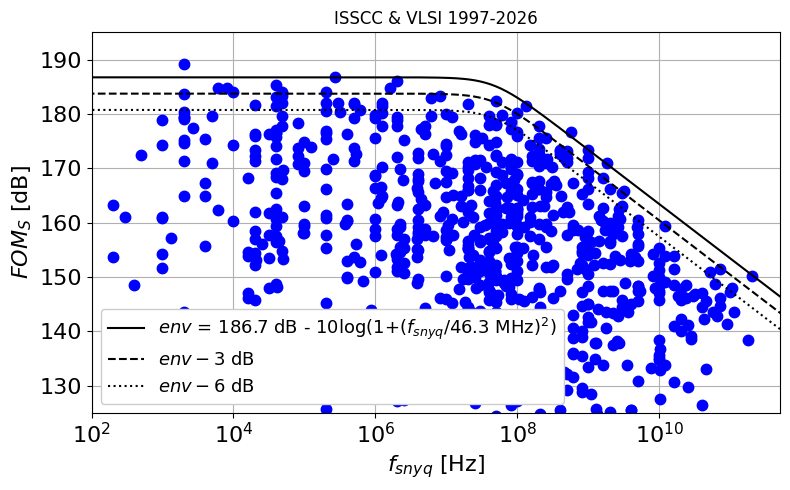

In [6]:
fig, ax = plt.subplots(figsize=size)
ax.plot(df['fsnyq [Hz]'], df['FOMS_hf [dB]'], 'b.', ms=15)
ax.plot(env_x, env_y, 'k', label='$env$ = %.1f dB - 10log(1+($f_{snyq}/$%.1f MHz$)^2)$' %(foms_db_asymp, f_corner/1e6))
ax.plot(env_x, env_y-3, 'k--', label='$env - 3$ dB')
ax.plot(env_x, env_y-6, 'k:', label='$env - 6$ dB')
ax.legend(frameon=1, loc='lower left', framealpha=1.0, fontsize=font-3)
ax.set_xscale('log')
ax.set_xlim((1e2, 500e9))
ax.set_ylim((125, 195))
plt.xticks(fontsize=font)
plt.yticks(fontsize=font)
plt.xlabel('$f_{snyq}$ [Hz]', fontsize=font)
plt.ylabel('$FOM_S$ [dB]', fontsize=font)
plt.title('ISSCC & VLSI 1997-%d' %max(df['YEAR']))
plt.grid(True)
fig.tight_layout()
plt.show()

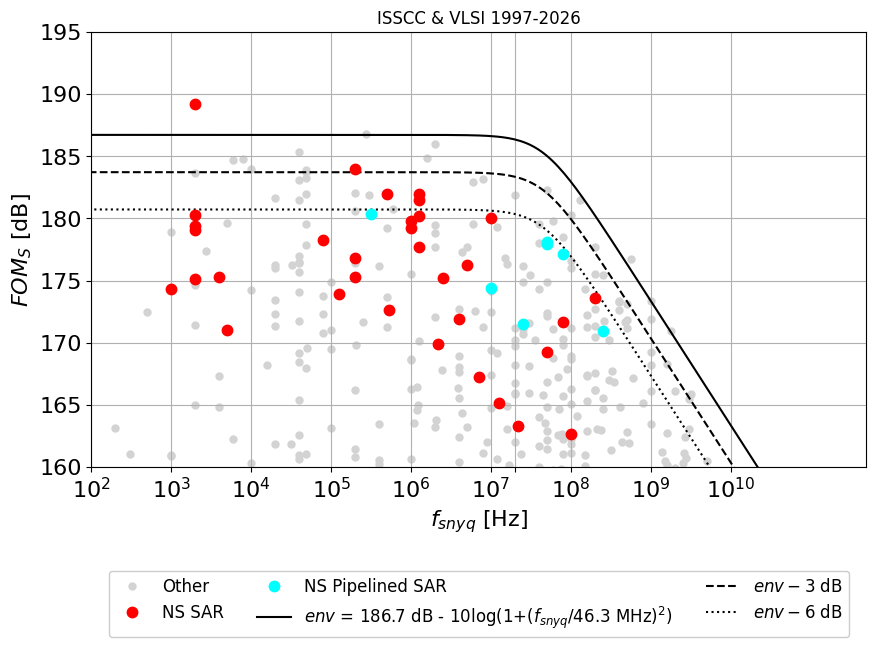

In [15]:
# ================= 配置区 =================
# 在这里配置你需要高亮的架构。
# 如果你不想高亮某个架构，只需在它的前面加上 # 注释掉即可，它将被自动归入 Other
highlight_targets = [
    #'SAR',
    'NS SAR',
    #'Pipelined SAR',
    'NS Pipelined SAR',
    #'TI SAR',
    #'NS TI SAR',
    #'TI Pipelined SAR',
    #'NS TI Pipelined SAR'
]
# ==========================================

# 1. 核心修改：仅通过 ARCHITECTURE 列的字段进行分类判断
def categorize_sar(row):
    # 将架构转为大写，方便统一匹配
    arch = str(row['ARCHITECTURE']).upper()

    # 如果没有 SAR，直接归为 Other
    if 'SAR' not in arch:
        return 'Other'

    # 在包含 SAR 的基础上，独立判断 TI, PIPE, NS 字段
    has_ti = 'TI' in arch
    has_pipe = 'PIPE' in arch
    has_ns = 'NS' in arch

    # 确定基础架构名称
    if has_ti and has_pipe:
        base_name = 'TI Pipelined SAR'
    elif has_ti:
        base_name = 'TI SAR'
    elif has_pipe:
        base_name = 'Pipelined SAR'
    else:
        base_name = 'SAR'

    # 根据是否包含 NS 加上前缀
    if has_ns:
        return 'NS ' + base_name
    else:
        return base_name

# 2. 将分类函数应用到 DataFrame
df['Original_Category'] = df.apply(categorize_sar, axis=1)

# 3. 根据用户的选择，过滤出最终用于绘图的分类
df['Plot_Category'] = df['Original_Category'].apply(
    lambda x: x if x in highlight_targets else 'Other'
)

# 4. 为所有可能的架构分配好颜色字典
color_map = {
    'Other': 'lightgray',
    'SAR': 'orange',
    'NS SAR': 'red',
    'Pipelined SAR': 'blue',
    'NS Pipelined SAR': 'cyan',
    'TI SAR': 'green',
    'NS TI SAR': 'lime',
    'TI Pipelined SAR': 'purple',
    'NS TI Pipelined SAR': 'magenta'
}

# 5. 开始绘图，保持增大的画布尺寸
fig, ax = plt.subplots(figsize=(10, 7.5))

# 先画出底层背景点（Other）
mask_other = df['Plot_Category'] == 'Other'
ax.plot(df[mask_other]['fsnyq [Hz]'], df[mask_other]['FOMS_hf [dB]'],
        '.', color=color_map['Other'], ms=10, label='Other', zorder=1)

# 循环画出被用户选中的 SAR 细分类别（放在上层）
for cat, color in color_map.items():
    if cat == 'Other':
        continue

    mask_cat = df['Plot_Category'] == cat
    if mask_cat.any():
        ax.plot(df[mask_cat]['fsnyq [Hz]'], df[mask_cat]['FOMS_hf [dB]'],
                '.', color=color, ms=15, label=cat, zorder=5)

# ===== 坐标轴与包络线设置 =====
ax.plot(env_x, env_y, 'k', label='$env$ = %.1f dB - 10log(1+($f_{snyq}/$%.1f MHz$)^2)$' %(foms_db_asymp, f_corner/1e6))
ax.plot(env_x, env_y-3, 'k--', label='$env - 3$ dB')
ax.plot(env_x, env_y-6, 'k:', label='$env - 6$ dB')

ax.set_xscale('log')
ax.set_xlim((1e2, 500e9))
ax.set_ylim((160, 195))
ax.set_xticks([1e2, 1e3, 1e4, 1e5, 1e6, 1e7, 2e7, 1e8, 1e9, 1e10])
plt.xticks(fontsize=font)
plt.yticks(fontsize=font)
plt.xlabel('$f_{snyq}$ [Hz]', fontsize=font)
plt.ylabel('$FOM_S$ [dB]', fontsize=font)
plt.title('ISSCC & VLSI 1997-%d' %max(df['YEAR']))
plt.grid(True)

# 图例防遮挡设置
ax.legend(frameon=1, loc='upper center', bbox_to_anchor=(0.5, -0.22),
          framealpha=1.0, fontsize=font-4, ncol=3)

# 调整底部边距
fig.subplots_adjust(bottom=0.30)

plt.show()

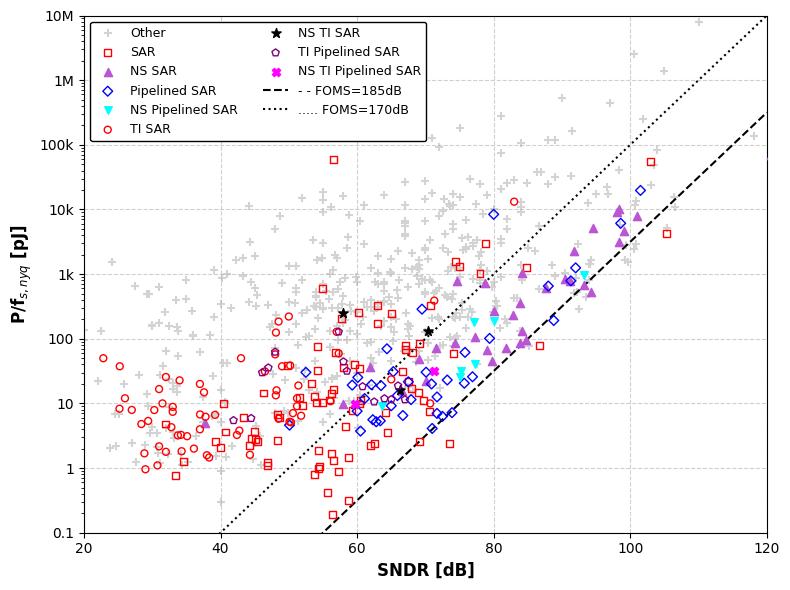

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ================= 1. 继承当前的分类逻辑 =================
def categorize_sar(row):
    arch = str(row['ARCHITECTURE']).upper()
    if 'SAR' not in arch:
        return 'Other'

    has_ti = 'TI' in arch
    has_pipe = 'PIPE' in arch
    has_ns = 'NS' in arch

    if has_ti and has_pipe:
        base_name = 'TI Pipelined SAR'
    elif has_ti:
        base_name = 'TI SAR'
    elif has_pipe:
        base_name = 'Pipelined SAR'
    else:
        base_name = 'SAR'

    if has_ns:
        return 'NS ' + base_name
    else:
        return base_name

# 应用分类
df['Plot_Category'] = df.apply(categorize_sar, axis=1)

# ================= 2. 为当前分类配置样式 (颜色与形状) =================
# 尽量仿照图片的空心/实心搭配，区分 8 种 SAR 和 Other
styles = {
    'Other':               {'marker': '+', 'color': 'lightgray', 's': 30},
    'SAR':                 {'marker': 's', 'facecolors': 'none', 'edgecolors': 'red', 's': 25},
    'NS SAR':              {'marker': '^', 'color': 'mediumorchid', 's': 35},
    'Pipelined SAR':       {'marker': 'D', 'facecolors': 'none', 'edgecolors': 'blue', 's': 25},
    'NS Pipelined SAR':    {'marker': 'v', 'color': 'cyan', 's': 30},
    'TI SAR':              {'marker': 'o', 'facecolors': 'none', 'edgecolors': 'red', 's': 25},
    'NS TI SAR':           {'marker': '*', 'color': 'black', 's': 50},
    'TI Pipelined SAR':    {'marker': 'p', 'facecolors': 'none', 'edgecolors': 'purple', 's': 30},
    'NS TI Pipelined SAR': {'marker': 'X', 'color': 'magenta', 's': 35}
}

# ================= 3. 开始绘制 P/fsnyq vs. SNDR =================
fig1, ax1 = plt.subplots(figsize=(8, 6))

# 过滤掉缺失所需数据的行
plot_df1 = df.dropna(subset=['SNDR_hf [dB]', 'P/fsnyq [pJ]'])

# 先画底层的 Other
mask_other = plot_df1['Plot_Category'] == 'Other'
ax1.scatter(plot_df1[mask_other]['SNDR_hf [dB]'], plot_df1[mask_other]['P/fsnyq [pJ]'],
            label='Other', zorder=1, **styles['Other'])

# 画出其他的 SAR 架构分类
for cat, style in styles.items():
    if cat == 'Other':
        continue
    mask_cat = plot_df1['Plot_Category'] == cat
    if mask_cat.any():
        ax1.scatter(plot_df1[mask_cat]['SNDR_hf [dB]'], plot_df1[mask_cat]['P/fsnyq [pJ]'],
                    label=cat, zorder=5, **style)

# 绘制 FOMs 等效虚线
# FOMS = SNDR - 10*log10(P/fsnyq * 10^-12)  =>  P/fsnyq = 10^((SNDR - FOMS)/10 + 12)
x_line = np.linspace(20, 120, 100)
y_185 = 10**((x_line - 185) / 10 + 12)
y_170 = 10**((x_line - 170) / 10 + 12)

ax1.plot(x_line, y_185, color='black', linestyle='--', label='- - FOMS=185dB', zorder=2)
ax1.plot(x_line, y_170, color='black', linestyle=':', label='..... FOMS=170dB', zorder=2)

# 坐标轴与范围设置
ax1.set_yscale('log')
ax1.set_xlim(20, 120)
ax1.set_ylim(0.1, 1e7)

# 自定义 Y 轴刻度标签格式 (仿照图片 1k, 1M, 10M)
ax1.set_yticks([1e-1, 1e0, 1e1, 1e2, 1e3, 1e4, 1e5, 1e6, 1e7])
ax1.set_yticklabels(['0.1', '1', '10', '100', '1k', '10k', '100k', '1M', '10M'])

ax1.grid(True, linestyle='--', alpha=0.6)
ax1.set_xlabel('SNDR [dB]', fontsize=12, fontweight='bold')
ax1.set_ylabel('P/f$_{s,nyq}$ [pJ]', fontsize=12, fontweight='bold')

# 放置图例 (仿照图片放在右下角，因为细分类较多，启用两列排列)
ax1.legend(loc='upper left', frameon=True, edgecolor='black', framealpha=1, fontsize=9, ncol=2)

fig1.tight_layout()
plt.show()

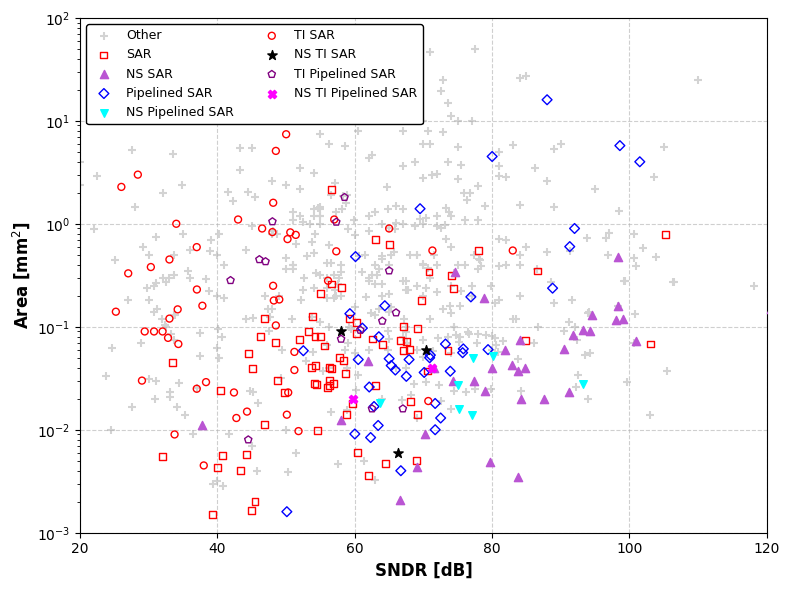

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# ================= 1. 分类逻辑 =================
def categorize_sar(row):
    arch = str(row['ARCHITECTURE']).upper()
    if 'SAR' not in arch:
        return 'Other'

    has_ti = 'TI' in arch
    has_pipe = 'PIPE' in arch
    has_ns = 'NS' in arch

    if has_ti and has_pipe:
        base_name = 'TI Pipelined SAR'
    elif has_ti:
        base_name = 'TI SAR'
    elif has_pipe:
        base_name = 'Pipelined SAR'
    else:
        base_name = 'SAR'

    if has_ns:
        return 'NS ' + base_name
    else:
        return base_name

# 应用分类到 DataFrame
df['Plot_Category'] = df.apply(categorize_sar, axis=1)

# ================= 2. 样式配置 (颜色与形状) =================
styles = {
    'Other':               {'marker': '+', 'color': 'lightgray', 's': 30},
    'SAR':                 {'marker': 's', 'facecolors': 'none', 'edgecolors': 'red', 's': 25},
    'NS SAR':              {'marker': '^', 'color': 'mediumorchid', 's': 35},
    'Pipelined SAR':       {'marker': 'D', 'facecolors': 'none', 'edgecolors': 'blue', 's': 25},
    'NS Pipelined SAR':    {'marker': 'v', 'color': 'cyan', 's': 30},
    'TI SAR':              {'marker': 'o', 'facecolors': 'none', 'edgecolors': 'red', 's': 25},
    'NS TI SAR':           {'marker': '*', 'color': 'black', 's': 50},
    'TI Pipelined SAR':    {'marker': 'p', 'facecolors': 'none', 'edgecolors': 'purple', 's': 30},
    'NS TI Pipelined SAR': {'marker': 'X', 'color': 'magenta', 's': 35}
}

# ================= 3. 数据清洗 (解决存在空格无法转换报错的问题) =================
df['SNDR_hf [dB]'] = pd.to_numeric(df['SNDR_hf [dB]'], errors='coerce')
df['AREA [mm^2]'] = pd.to_numeric(df['AREA [mm^2]'], errors='coerce')

# 过滤确实所需数据的行
plot_df2 = df.dropna(subset=['SNDR_hf [dB]', 'AREA [mm^2]'])

# ================= 4. 开始绘制 Area vs. SNDR =================
fig2, ax2 = plt.subplots(figsize=(8, 6))

# 先画底层的 Other (浅灰色十字)
mask_other2 = plot_df2['Plot_Category'] == 'Other'
ax2.scatter(plot_df2[mask_other2]['SNDR_hf [dB]'], plot_df2[mask_other2]['AREA [mm^2]'],
            label='Other', zorder=1, **styles['Other'])

# 画其他的 SAR 架构分类
for cat, style in styles.items():
    if cat == 'Other':
        continue
    mask_cat2 = plot_df2['Plot_Category'] == cat
    if mask_cat2.any():
        ax2.scatter(plot_df2[mask_cat2]['SNDR_hf [dB]'], plot_df2[mask_cat2]['AREA [mm^2]'],
                    label=cat, zorder=5, **style)

# ================= 5. 坐标系与刻度设置 =================
ax2.set_yscale('log')
ax2.set_xlim(20, 120)
ax2.set_ylim(1e-3, 1e2)

# 网格与标题设置
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.set_xlabel('SNDR [dB]', fontsize=12, fontweight='bold')
ax2.set_ylabel('Area [mm$^2$]', fontsize=12, fontweight='bold')

# 放置图例
ax2.legend(loc='upper left', frameon=True, edgecolor='black', framealpha=1, fontsize=9, ncol=2)

fig2.tight_layout()
plt.show()

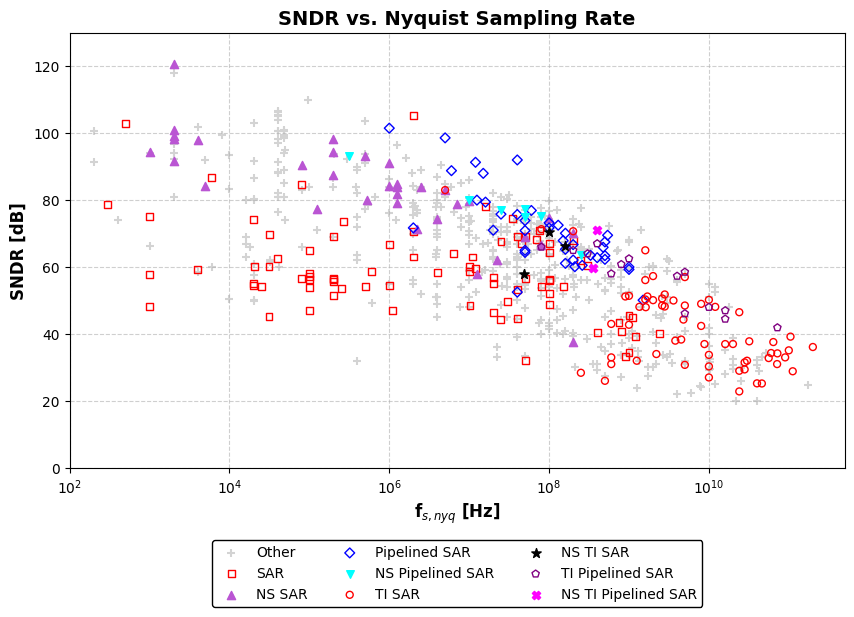

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# ================= 1. 分类逻辑 =================
def categorize_sar(row):
    arch = str(row['ARCHITECTURE']).upper()
    if 'SAR' not in arch:
        return 'Other'

    has_ti = 'TI' in arch
    has_pipe = 'PIPE' in arch
    has_ns = 'NS' in arch

    if has_ti and has_pipe:
        base_name = 'TI Pipelined SAR'
    elif has_ti:
        base_name = 'TI SAR'
    elif has_pipe:
        base_name = 'Pipelined SAR'
    else:
        base_name = 'SAR'

    if has_ns:
        return 'NS ' + base_name
    else:
        return base_name

# 应用分类到 DataFrame
df['Plot_Category'] = df.apply(categorize_sar, axis=1)

# ================= 2. 样式配置 (颜色与形状) =================
styles = {
    'Other':               {'marker': '+', 'color': 'lightgray', 's': 30},
    'SAR':                 {'marker': 's', 'facecolors': 'none', 'edgecolors': 'red', 's': 25},
    'NS SAR':              {'marker': '^', 'color': 'mediumorchid', 's': 35},
    'Pipelined SAR':       {'marker': 'D', 'facecolors': 'none', 'edgecolors': 'blue', 's': 25},
    'NS Pipelined SAR':    {'marker': 'v', 'color': 'cyan', 's': 30},
    'TI SAR':              {'marker': 'o', 'facecolors': 'none', 'edgecolors': 'red', 's': 25},
    'NS TI SAR':           {'marker': '*', 'color': 'black', 's': 50},
    'TI Pipelined SAR':    {'marker': 'p', 'facecolors': 'none', 'edgecolors': 'purple', 's': 30},
    'NS TI Pipelined SAR': {'marker': 'X', 'color': 'magenta', 's': 35}
}

# ================= 3. 数据清洗 =================
# 强制转换为数值格式，遇到非法字符(如空格)强制置为 NaN
df['fsnyq [Hz]'] = pd.to_numeric(df['fsnyq [Hz]'], errors='coerce')
df['SNDR_hf [dB]'] = pd.to_numeric(df['SNDR_hf [dB]'], errors='coerce')

# 过滤确实所需数据的行
plot_df3 = df.dropna(subset=['fsnyq [Hz]', 'SNDR_hf [dB]'])

# ================= 4. 开始绘制 SNDR vs. fsnyq =================
fig3, ax3 = plt.subplots(figsize=(10, 7.5))

# 先画底层的 Other (浅灰色十字)
mask_other3 = plot_df3['Plot_Category'] == 'Other'
ax3.scatter(plot_df3[mask_other3]['fsnyq [Hz]'], plot_df3[mask_other3]['SNDR_hf [dB]'],
            label='Other', zorder=1, **styles['Other'])

# 画其他的 SAR 架构分类
for cat, style in styles.items():
    if cat == 'Other':
        continue
    mask_cat3 = plot_df3['Plot_Category'] == cat
    if mask_cat3.any():
        ax3.scatter(plot_df3[mask_cat3]['fsnyq [Hz]'], plot_df3[mask_cat3]['SNDR_hf [dB]'],
                    label=cat, zorder=5, **style)

# ================= 5. 坐标系与刻度设置 =================
# 横轴采样频率一般用对数系，纵轴SNDR用线性系
ax3.set_xscale('log')
ax3.set_xlim(1e2, 500e9)
ax3.set_ylim(0, 130)

# 网格与标题设置
ax3.grid(True, linestyle='--', alpha=0.6)
ax3.set_xlabel('f$_{s,nyq}$ [Hz]', fontsize=12, fontweight='bold')
ax3.set_ylabel('SNDR [dB]', fontsize=12, fontweight='bold')
ax3.set_title('SNDR vs. Nyquist Sampling Rate', fontsize=14, fontweight='bold')

# 放置图例 (放在底部图表外侧以防遮挡数据，分成 3 列)
ax3.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
           frameon=True, edgecolor='black', framealpha=1, fontsize=10, ncol=3)

# 调整图表底部的边距，给下方的图例腾出足够空间
fig3.subplots_adjust(bottom=0.3)

plt.show()

In [ ]:
# save as high-resolution png file
if IN_COLAB:
   files.download('foms_plot.png')
else:
   fig.savefig("foms_plot.png", dpi=600)

In [ ]:
# save parameters as json file
data = {
    "foms_db_asymp": foms_db_asymp,
    "f_corner": f_corner,
}
file_name = "foms_plot.json"
try:
    with open(file_name, "w") as json_file:
        json.dump(data, json_file, indent=4)
    print(f"Data successfully written to {file_name}")
except IOError as e:
    print(f"Error writing to file: {e}")

Data successfully written to foms_plot.json
